In [34]:
import cudaq
from typing import List
import numpy as np
from matplotlib import pyplot as plt

In [2]:
%env CUDAQ_QUANTINUUM_CREDENTIALS=./env/.quantinuum_config
# !cat $CUDAQ_QUANTINUUM_CREDENTIALS

env: CUDAQ_QUANTINUUM_CREDENTIALS=./env/.quantinuum_config


In [5]:
# cudaq.set_target('quantinuum', project='Project-Test', machine='H2-1')
cudaq.set_target("nvidia")

In [6]:
@cudaq.kernel
def kernel_oracle(v: cudaq.qvector, r: cudaq.qubit, l: List[int]):
    qb = len(v)
    for k in l:
        for i in range(qb):
            if int(k / (2**i)) % 2 == 0:
                x(v[qb - i - 1])
        x.ctrl(v, r)
        for i in range(qb):
            if int(k / (2**i)) % 2 == 0:
                x(v[qb - i - 1])

@cudaq.kernel
def kernel_diffuser(v: cudaq.qvector):
    qb = len(v)
    h(v)
    x(v)
    z.ctrl([*v[0:qb-1]], v[qb-1])
    x(v)
    h(v)

@cudaq.kernel
def kernel_grover(qb:int, l: List[int], iterations: int):
    v = cudaq.qvector(qb)
    r = cudaq.qubit()
    h(v)
    x(r)
    h(r)
    for _ in range(iterations):
        kernel_oracle(v, r, l)
        kernel_diffuser(v) 
    mz(v)

print(cudaq.draw(kernel_grover, 3, [3], 1))

     ╭───╮╭───╮     ╭───╮╭───╮╭───╮     ╭───╮╭───╮
q0 : ┤ h ├┤ x ├──●──┤ x ├┤ h ├┤ x ├──●──┤ x ├┤ h ├
     ├───┤╰───╯  │  ├───┤├───┤╰───╯  │  ├───┤├───┤
q1 : ┤ h ├───────●──┤ h ├┤ x ├───────●──┤ x ├┤ h ├
     ├───┤       │  ├───┤├───┤     ╭─┴─╮├───┤├───┤
q2 : ┤ h ├───────●──┤ h ├┤ x ├─────┤ z ├┤ x ├┤ h ├
     ├───┤╭───╮╭─┴─╮╰───╯╰───╯     ╰───╯╰───╯╰───╯
q3 : ┤ x ├┤ h ├┤ x ├──────────────────────────────
     ╰───╯╰───╯╰───╯                              



In [43]:
qb = 7
nums = [68, 103, 119, 45]

zeta = np.arcsin(np.sqrt(len(nums) / (2 ** qb)))
print(f'zeta: {zeta / np.pi * 180:.2f}')

iters = round(np.pi / (4 * zeta) - 0.5)
print(f'\nOptimal iterations: {iters}')
optimal_zeta = zeta * (2 * iters + 1)
print(f'Optimal zeta: {optimal_zeta / np.pi * 180:.2f}')

probs_true = np.abs(np.sin(optimal_zeta)) ** 2
probs_false = np.abs(np.cos(optimal_zeta)) ** 2

zeta: 10.18

Optimal iterations: 4
Optimal zeta: 91.64


In [ ]:
assert False

In [6]:
shots = 1000
results = cudaq.sample(kernel_grover, qb, nums, iters, shots_count=shots)
# print(results)

result_final = np.zeros(2**qb)
probs = np.zeros_like(result_final)
pt = 0
# for i in results:
#     result_final[int(i, 2)] = results[i]
#     probs[int(i, 2)] = results[i] / shots
#     if int(i, 2) in nums:
#         pt += probs[int(i, 2)]
# # print(probs)
# print(f'Probability of measuring True: {pt:.5f}')
# print(f'Probability of Theoretical True: {probs_true:.5f}')

# print(f'\nProbability of measuring False: {1-pt:.5f}')
# print(f'Probability of Theoretical False: {probs_false:.5f}')

RuntimeError: HTTP GET Error - status code 0: Recv failure: Unknown error 101: 

In [ ]:
# print(results)

In [ ]:
# for i, j in results.items():
#     ii = ""
#     for k in range(0, len(i), 64):
#         ii += i[k]
#     print(f'{int(ii, 2)}: {j}')

In [ ]:
for i, j in results.items():
    ii = ""
    for k in range(0, len(i), 64):
        ii += i[k]
    result_final[int(ii, 2)] = j
    probs[int(ii, 2)] = j / shots
    if int(ii, 2) in nums:
        pt += probs[int(ii, 2)]
# print(probs)
print(f'Probability of measuring True: {pt:.5f}')
print(f'Probability of Theoretical True: {probs_true:.5f}')

print(f'\nProbability of measuring False: {1-pt:.5f}')
print(f'Probability of Theoretical False: {probs_false:.5f}')

Probability of measuring True: 0.27300
Probability of Theoretical True: 0.99918

Probability of measuring False: 0.72700
Probability of Theoretical False: 0.00082


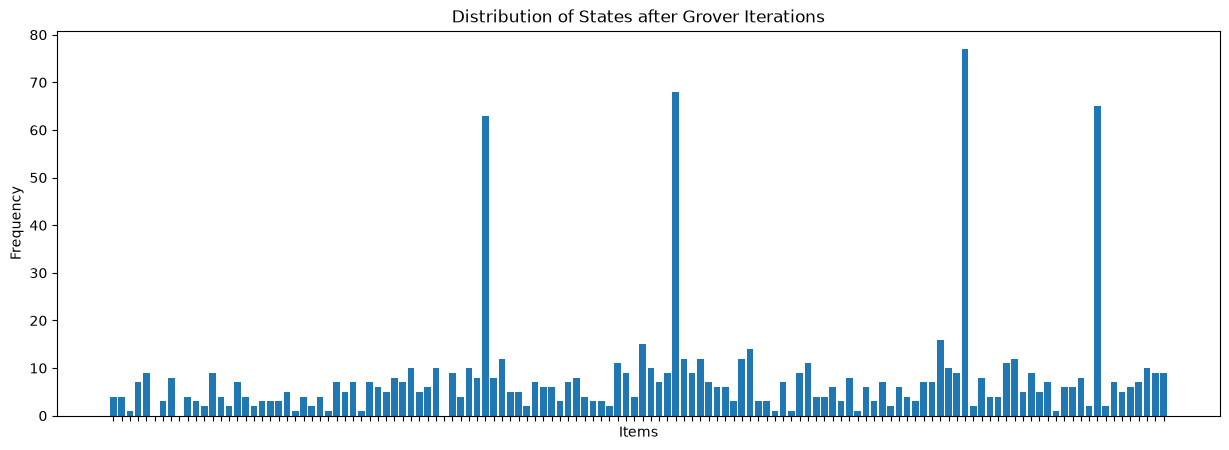

In [ ]:
plt.figure(figsize=(15, 5))
x = np.arange(2**qb)
plt.bar(range(2**qb), result_final)

plt.xlabel('Items')
plt.ylabel('Frequency')
plt.title('Distribution of States after Grover Iterations')

# plt.xticks(x, [f"{i:0{qb}b}" for i in x])
# plt.xticks(x, [f"{i}" for i in x])
plt.xticks(x, [f"" for i in x])
plt.gca().set_xticklabels([])
plt.xticks(visible=False)


xlocs, xlabs = plt.xticks()
for i, s in enumerate(probs):
    if s > 0.1:
        plt.text(xlocs[i]-1, result_final[i] + shots/200, f"({i}: {s:.3f})")
plt.show()

In [ ]:
import qnexus as qnx
qnx.login()

In [5]:
my_job_ref = qnx.jobs.get(id="6d50b863-d554-47fc-a95b-36b675f660fa")

In [14]:
results = qnx.jobs.results(my_job_ref)[0]

In [16]:
results_final = results.download_result()

Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `U1q`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `ZZ`, will omit from BackendInfo. Consider updating your pytket version.


In [46]:
shots = 1000

In [48]:
results_counter = results_final.get_empirical_distribution().as_counter()
l = list(results_counter.keys())

result_final = np.zeros(2**qb)
probs = np.zeros_like(result_final)
pt = 0

for i in l:
    j = results_counter[i]
    ii = ""
    for k in range(0, len(i), 64):
        ii += str(i[k])
    result_final[int(ii, 2)] = j
    probs[int(ii, 2)] = j / shots
    if int(ii, 2) in nums:
        pt += probs[int(ii, 2)]

print(f'Probability of measuring True: {pt:.5f}')
print(f'Probability of Theoretical True: {probs_true:.5f}')

print(f'\nProbability of measuring False: {1-pt:.5f}')
print(f'Probability of Theoretical False: {probs_false:.5f}')

Probability of measuring True: 0.21400
Probability of Theoretical True: 0.99918

Probability of measuring False: 0.78600
Probability of Theoretical False: 0.00082


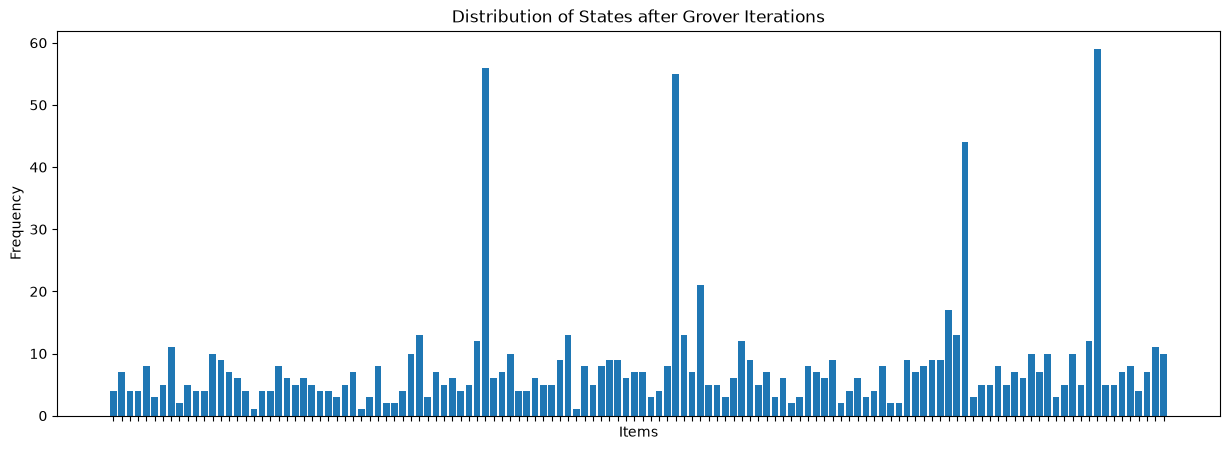

In [49]:
plt.figure(figsize=(15, 5))
x = np.arange(2**qb)
plt.bar(range(2**qb), result_final)

plt.xlabel('Items')
plt.ylabel('Frequency')
plt.title('Distribution of States after Grover Iterations')

# plt.xticks(x, [f"{i:0{qb}b}" for i in x])
# plt.xticks(x, [f"{i}" for i in x])
plt.xticks(x, [f"" for i in x])
plt.gca().set_xticklabels([])
plt.xticks(visible=False)


xlocs, xlabs = plt.xticks()
for i, s in enumerate(probs):
    if s > 0.1:
        plt.text(xlocs[i]-1, result_final[i] + shots/200, f"({i}: {s:.3f})")
plt.show()